# The Cas A light-echo analysis, run end to end

This notebook **runs the pipeline**. It starts from the resampled JWST epoch
cube, computes 3D structure functions, fits ellipsoids with jackknife errors,
writes the result tables, and draws the paper's figures from the tables it just
produced.

Its companion, `topline_results.ipynb`, does the opposite: it reads the
*tracked* tables and checks the report's numbers against them. Use that one to
audit the claims; use this one to regenerate the evidence.

### What you need

The bulk input arrays, symlinked into `data/` (see `README_FORK.md`):

    resampled_epochs_noclip.npy   1.5 G    the five reduced epochs
    U_grid.npy  V_grid.npy        303 M    echo-plane coordinates per pixel
    epoch_mean_w.npy                4 K    W depth of each epoch
    edge_mask_r50.npy             189 M    eroded validity mask

`data/chunk_windows.csv` (the 115-window map) is tracked. A bare clone
**cannot** run this notebook; the first cell checks and says so.

### The measurement, in one paragraph

A light echo is a sheet of dust lit up by the supernova flash. As time passes
the illuminated sheet sweeps through the cloud, so each JWST epoch images a
different *slice* of the same 3D dust distribution. Convert (RA, Dec, epoch) to
a coordinate system centred on Cas A, rotate so that **W** is perpendicular to
the echo plane and **U, V** lie in it, and the observation becomes a genuine 3D
scalar field sampled on a very anisotropic grid: fine in U and V (sub-milliparsec
pixels), coarse in W (five epochs). The second-order structure function
S₂(dU, dV, dW) of that field is then fit with an anisotropic model whose
iso-S₂ surfaces are ellipsoids. The axis ratios of those ellipsoids are the
measurement.

### What gets run, and what it costs

Measured on 12 cores, with `PROCS` workers:

| stage | scope | measured cost |
|---|---|---|
| §1 one window, in detail | 1 window | ~20 s |
| §2 noise audit / SNR tiers | 115 windows | ~15 s |
| §3 single-band fits, `k=3` | 29 top-SNR windows | ~3.5 min |
| §4 single-band fits, `k=4` | all 115 windows | ~25 min |
| §5 figures | from §3 + §4 | ~10 s |
| §6 scale profile (`RUN_LEVEL='full'`) | 29 windows × 5 bands | ~30 min |

§2 is cheap because the audit needs only `compute_s2`, no fitting; §4 dominates
because it is 115 windows × 17 fits.

Set `RUN_LEVEL` in the next cell. Per-window results are cached as JSON, so an
interrupted run resumes instead of restarting.

In [1]:
import json
import os
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == \
    'notebooks' else os.getcwd()
sys.path[:0] = [ROOT, os.path.join(ROOT, 'analysis')]

# ---- knobs ---------------------------------------------------------------
RUN_LEVEL = 'full'      # 'walkthrough' | 'figures' | 'full'
PROCS = 6               # worker processes for the window pools
STRIDE = 2              # lag-grid decimation used by every published fit
RCUT = 0.1              # single-band fit radius, light years
# -------------------------------------------------------------------------

LEVELS = ['walkthrough', 'figures', 'full']
assert RUN_LEVEL in LEVELS
LEVEL = LEVELS.index(RUN_LEVEL)

# Everything this notebook computes lands here, mirroring the repo layout.
# The tracked results/ and data/ trees are never written to, so a rerun can be
# diffed against the published numbers.
RERUN = os.path.join(ROOT, 'rerun')
os.makedirs(os.path.join(RERUN, 'results'), exist_ok=True)
os.makedirs(os.path.join(RERUN, 'data'), exist_ok=True)

REQUIRED = ['resampled_epochs_noclip.npy', 'U_grid.npy', 'V_grid.npy',
            'epoch_mean_w.npy', 'edge_mask_r50.npy']
missing = [f for f in REQUIRED
           if not os.path.exists(os.path.join(ROOT, 'data', f))]
print('repo      :', ROOT)
print('rerun into:', RERUN)
print('level     : %s (%d of %d)' % (RUN_LEVEL, LEVEL + 1, len(LEVELS)))
if missing:
    print()
    print('MISSING bulk inputs -> this notebook cannot run:')
    for f in missing:
        print('   ', f)
    print('See README_FORK.md.  topline_results.ipynb runs without them.')
else:
    tot = sum(os.path.getsize(os.path.realpath(os.path.join(ROOT, 'data', f)))
              for f in REQUIRED)
    print('inputs    : all %d present (%.1f GB)' % (len(REQUIRED), tot / 1e9))
assert not missing, 'bulk input arrays absent; see README_FORK.md'

repo      : /Users/jegpeek/Repositories/casa
rerun into: /Users/jegpeek/Repositories/casa/rerun
level     : full (3 of 3)
inputs    : all 5 present (2.4 GB)


In [2]:
import structure_function as sf
import scale_split as ss
import singleband_powerlaw as sbp
import noise_audit as na

windows = pd.read_csv(os.path.join(ROOT, 'data', 'chunk_windows.csv'))
print('window map : %d windows of %d px' % (len(windows), windows['size'].iloc[0]))
print()
print('read options (READ_KW)   :', ss.READ_KW)
print('S2 options   (COMPUTE_KW):', ss.COMPUTE_KW)
print('fit options  (FIT_KW)    :', ss.FIT_KW)
print()
print('These four dicts are the entire configuration of the published fits.')
print('They live in analysis/scale_split.py and every driver imports them from')
print('there, so the notebook cannot silently fit with different settings.')

window map : 115 windows of 400 px

read options (READ_KW)   : {'edge_mask_radius': 50, 'min_coverage': 0.25}
S2 options   (COMPUTE_KW): {'background': 0.03, 'arcsinh_scale': 0.03, 'assume_stationary': True}
fit options  (FIT_KW)    : {'max_nfev': None, 'weighting': '1/r', 'min_n_fraction': 0.1}

These four dicts are the entire configuration of the published fits.
They live in analysis/scale_split.py and every driver imports them from
there, so the notebook cannot silently fit with different settings.


## 1. One window, from pixels to an ellipsoid

Before running anything at scale, here is the whole measurement on a single
400 × 400 pixel window, in four steps. This is what each of the 115 windows
costs, and what the drivers in §2–§4 do in a loop.

`read_window(row0, col0, nrows, ncols)` cuts the window out of the full-sky
cube. Note the argument order — **row first** — a trap worth stating because the
window map lists `row, col` and the images are indexed the same way.

The window is masked twice: an eroded edge mask (`edge_mask_radius=50`) removes
pixels near the map boundary where the resampling has no support, and any epoch
covering less than 25 % of the window is blanked entirely (`min_coverage=0.25`).
Interior windows come through fully covered; windows near the footprint edge
lose a substantial fraction. Because coverage is ragged and epoch-dependent, S₂
is computed by explicit pair counting rather than by FFT — an FFT would need a
filled grid and would silently treat blanked pixels as zeros.

In [3]:
W0 = dict(row=2000, col=2800, size=400)   # a high-SNR window
t0 = time.time()
data = sf.read_window(W0['row'], W0['col'], W0['size'], W0['size'],
                      data_dir=os.path.join(ROOT, 'data'), **ss.READ_KW)
print('read_window(%d, %d) : %.1f s' % (W0['row'], W0['col'], time.time() - t0))

flux = data['flux_epochs']
print()
print('flux_epochs  :', flux.shape, '(epoch, row, col)')
print('finite pixels: %.1f %% of %d' % (100 * np.isfinite(flux).mean(), flux.size))
print('per epoch    :', ['%.0f%%' % (100 * np.isfinite(f).mean()) for f in flux])

# An edge window, for contrast -- this is what the masking actually costs.
edge = sf.read_window(400, 1600, 400, 400,
                      data_dir=os.path.join(ROOT, 'data'), **ss.READ_KW)
print('edge window r400 c1600: %.1f %% finite, per epoch %s'
      % (100 * np.isfinite(edge['flux_epochs']).mean(),
         ['%.0f%%' % (100 * np.isfinite(f).mean())
          for f in edge['flux_epochs']]))
del edge
print()
print('U range : %.3f to %.3f ly' % (data['U_grid'].min(), data['U_grid'].max()))
print('V range : %.3f to %.3f ly' % (data['V_grid'].min(), data['V_grid'].max()))
wv = np.asarray(data['W_values'])
print('W depths: %s ly  (one per epoch)' % np.array2string(wv, precision=3))
print()
print('So the sampled volume is ~%.2f x %.2f ly across the echo plane and'
      % (np.ptp(data['U_grid']), np.ptp(data['V_grid'])))
print('%.2f ly deep, sampled at just %d depths -- the extreme anisotropy the'
      % (np.ptp(wv), len(wv)))
print('fit has to cope with, and the reason W errors dominate.')

read_window(2000, 2800) : 0.1 s

flux_epochs  : (5, 400, 400) (epoch, row, col)
finite pixels: 100.0 % of 800000
per epoch    : ['100%', '100%', '100%', '100%', '100%']
edge window r400 c1600: 59.8 % finite, per epoch ['0%', '100%', '100%', '0%', '99%']

U range : 106.437 to 107.076 ly
V range : 55.192 to 55.830 ly
W depths: [201.812 201.857 201.879 201.904 202.026] ly  (one per epoch)

So the sampled volume is ~0.64 x 0.64 ly across the echo plane and
0.21 ly deep, sampled at just 5 depths -- the extreme anisotropy the
fit has to cope with, and the reason W errors dominate.


### 1.2 The structure function

`compute_s2` forms S₂(dU, dV, dW) = ⟨[f(x+r) − f(x)]²⟩ over every valid pixel
pair, for each of the 15 epoch pairs (5 same-epoch planes at dW = 0, plus 10
cross-epoch planes at finite dW). Flux is arcsinh-stretched first
(`arcsinh_scale=0.03`) so that the bright echo ridge does not dominate the
variance, and a constant background is removed.

The output is a (15, 799, 799) cube: 15 dW planes, each a 799 × 799 grid of
in-plane lags. Counts per lag bin are returned alongside, and the fit weights by
them.

In [4]:
t0 = time.time()
s2 = sf.compute_s2(data, **ss.COMPUTE_KW)
print('compute_s2 : %.1f s' % (time.time() - t0))
print()
print('s2       :', s2['s2'].shape, '(epoch pair, lag_dv, lag_du)')
print('n_counts :', s2['n_counts'].shape, 'pairs contributing to each bin')
print('epoch_pairs:', s2['epoch_pairs'])
same = [i for i, (a, b) in enumerate(s2['epoch_pairs']) if a == b]
print('   -> %d same-epoch planes (dW = 0) at indices %s' % (len(same), same))
print('   -> %d cross-epoch planes carry all the dW information' %
      (len(s2['epoch_pairs']) - len(same)))
print()
print('lag_du : %d values, %.4f to %.4f ly' %
      (len(s2['lag_du']), s2['lag_du'].min(), s2['lag_du'].max()))
print('lag_dw : %s ly' % np.array2string(s2['lag_dw'], precision=3))
print()
tot = np.nansum(s2['n_counts'])
print('total pixel pairs binned: %.2e' % tot)

compute_s2 : 0.4 s

s2       : (15, 799, 799) (epoch pair, lag_dv, lag_du)
n_counts : (15, 799, 799) pairs contributing to each bin
epoch_pairs: [(0, 0), (1, 1), (2, 2), (3, 3), (4, 4), (0, 1), (0, 2), (0, 3), (0, 4), (1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4)]
   -> 5 same-epoch planes (dW = 0) at indices [0, 1, 2, 3, 4]
   -> 10 cross-epoch planes carry all the dW information

lag_du : 799 values, -0.6384 to 0.6384 ly
lag_dw : [0.    0.    0.    0.    0.    0.045 0.067 0.093 0.214 0.022 0.048 0.169
 0.026 0.147 0.121] ly

total pixel pairs binned: 3.81e+11


### 1.3 The fit

`_fit_all_modes` fits four models to the same S₂: a power law and a Weibull
profile, each in 3D (all 15 planes) and in the dW = 0 plane only ("2D"). The 3D
power law is the published fit; the 2D fit is the independent in-plane
measurement used to test the slicing hypothesis.

The model separates *shape* from *profile*. A lower-triangular matrix **M**
(parameters `s11, s22, s33, l12, l13, l23`) maps a lag vector to an ellipsoidal
radius r = |M⁻¹ **dx**|, and S₂ is a function of that radius alone. Iso-S₂
surfaces are therefore ellipsoids, and the axis ratios a₂/a₁, a₃/a₂ come from
**M**'s singular values — not from the profile shape. That separation is what
makes the ratios robust while the absolute sizes are not.

In [5]:
t0 = time.time()
central, r_grid = sbp._fit_all_modes(data, RCUT, STRIDE)
print('_fit_all_modes (4 models) : %.1f s' % (time.time() - t0))
print()
fit3d = central[('3d', 'powerlaw')]
fit2d = central[('2d', 'powerlaw')]

print('3D power law, the published fit:')
for k in ['a1', 'a2', 'a3', 'a2a1', 'a3a2', 'a3a1', 'alpha', 'incl',
          'n_fit', 'chi2', 'fit_success']:
    v = fit3d[k]
    print('   %-11s %s' % (k, ('%.5g' % v) if isinstance(v, float) else v))
print()
print('axes 1 : %.4f : %.4f   (a1 = %.3f ly)'
      % (fit3d['a2a1'], fit3d['a3a2'] * fit3d['a2a1'], fit3d['a1']))
print('long axis sits %.1f deg from the echo normal W' % fit3d['incl'])
print()
print('in-plane slice b2/b1 : %.4f predicted by the 3D fit above'
      % fit3d['b2b1'])
print('                       %.4f from the independent 2D fit'
      % fit2d['b2b1'])
print()
print('Those two are different measurements of the same quantity: the first is')
print('what the 3D ellipsoid implies its dW=0 central slice must look like, the')
print('second fits that slice on its own.  Agreement is a real consistency')
print('check, and confusing them turns it into a circular one.')

_fit_all_modes (4 models) : 2.0 s

3D power law, the published fit:
   a1          0.22539
   a2          0.061323
   a3          0.04485
   a2a1        0.27208
   a3a2        0.73138
   a3a1        0.19899
   alpha       0.61906
   incl        75.949
   n_fit       27938
   chi2        2.1037e+05
   fit_success True

axes 1 : 0.2721 : 0.1990   (a1 = 0.225 ly)
long axis sits 75.9 deg from the echo normal W

in-plane slice b2/b1 : 0.4241 predicted by the 3D fit above
                       0.4620 from the independent 2D fit

Those two are different measurements of the same quantity: the first is
what the 3D ellipsoid implies its dW=0 central slice must look like, the
second fits that slice on its own.  Agreement is a real consistency
check, and confusing them turns it into a circular one.


### 1.4 The error bar

Errors come from a **delete-one-block spatial jackknife**: the window is cut
into k × k blocks, the fit repeated with each block removed, and the scatter
across the k² refits scaled up in the usual jackknife way. Blocks rather than
individual pixels, because neighbouring pixels are correlated — that is the
signal being measured.

`--k` is not cosmetic. `k=2` does not converge; `k=3` and `k=4` agree to about
1 %. The report tabulates `k=3`, the figures use `k=4`.

In [6]:
K_DEMO = 3
t0 = time.time()
jk = []
for i in range(K_DEMO):
    for j in range(K_DEMO):
        d2 = ss._delete_block(data, i, j, K_DEMO)
        f2, _ = sbp._fit_all_modes(d2, RCUT, STRIDE, r_grid=r_grid)
        jk.append(f2[('3d', 'powerlaw')])
print('%d jackknife refits : %.1f s' % (len(jk), time.time() - t0))
print()
n = len(jk)
for q in ['a2a1', 'a3a2', 'incl']:
    vals = np.array([r[q] for r in jk], dtype=float)
    ok = np.isfinite(vals)
    # delete-one jackknife SE, log space for ratios (the fitted quantity)
    if q != 'incl':
        lv = np.log10(vals[ok])
        se = np.sqrt((ok.sum() - 1) * np.var(lv, ddof=0))
        print('%-6s central %.4f   jackknife SE %.4f dex  (%d/%d converged)'
              % (q, central[('3d', 'powerlaw')][q], se, ok.sum(), n))
    else:
        se = np.sqrt((ok.sum() - 1) * np.var(vals[ok], ddof=0))
        print('%-6s central %.1f deg  jackknife SE %.1f deg  (%d/%d converged)'
              % (q, central[('3d', 'powerlaw')][q], se, ok.sum(), n))
print()
print('One window therefore costs 1 + k^2 fits: %d at k=3, %d at k=4.'
      % (1 + 9, 1 + 16))
print()
print('NB the se_* columns in the result tables are LINEAR, not dex; the shape')
print('estimators convert internally.  The loop above is a transparent')
print('re-implementation, so it will not match the driver to the last digit --')
print('the driver reuses one r_grid across refits and handles non-converged')
print('blocks slightly differently.  Section 3 compares against the driver')
print('output proper, which is the number that matters.')

9 jackknife refits : 18.6 s

a2a1   central 0.2721   jackknife SE 0.1068 dex  (9/9 converged)
a3a2   central 0.7314   jackknife SE 0.1117 dex  (9/9 converged)
incl   central 75.9 deg  jackknife SE 3.4 deg  (9/9 converged)

One window therefore costs 1 + k^2 fits: 10 at k=3, 17 at k=4.

NB the se_* columns in the result tables are LINEAR, not dex; the shape
estimators convert internally.  The loop above is a transparent
re-implementation, so it will not match the driver to the last digit --
the driver reuses one r_grid across refits and handles non-converged
blocks slightly differently.  Section 3 compares against the driver
output proper, which is the number that matters.


### 1.5 What the window actually looks like

Two diagnostics, both from `structure_function.py`. The RGB composite shows the
first three epochs as colour channels, so the echo's apparent motion between
epochs appears as colour fringing; the arrows are the motion the fitted geometry
predicts. The 1D plot collapses S₂ onto ellipsoidal radius — if the fit is good,
the 15 planes fall on **one** curve in that metric, which is the whole claim of
the anisotropic model.

raw fit reproduces the table fit: a2a1 0.272082 vs 0.272082, a3a2 0.731376 vs 0.731376
wrote rerun/results/one_window_diagnostics.png


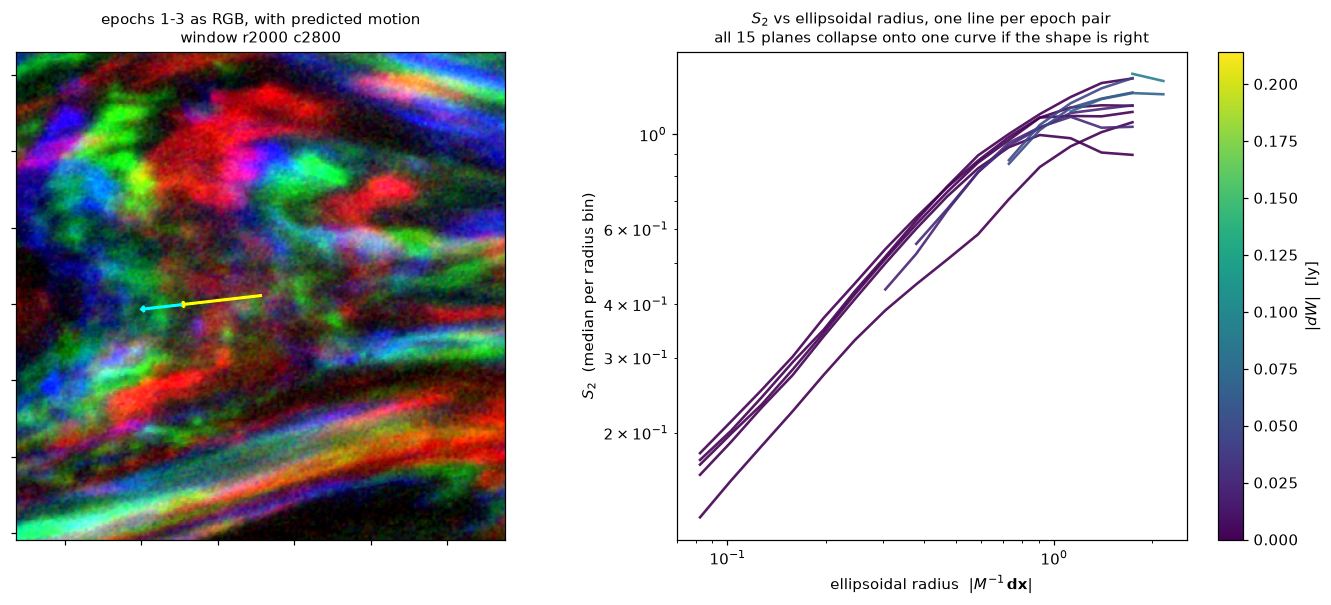

In [7]:
# The plot helpers want the RAW fit object -- fit['params'], fit['fit_weight'] --
# whereas _fit_all_modes above returns the flattened scalar dict that the result
# tables are built from.  So call sf.fit_s2 once directly, on the same banded S2
# the published fit uses.  A trap worth naming: passing the flattened dict to
# these helpers raises KeyError('params').
band = ss._banded(s2, r_grid, 0.0, RCUT)
raw = sf.fit_s2(band, profile=sf.power_law_log_s2, freeze=('A',),
                inner_uv_pixels=ss.INNER_UV,
                **dict(ss.FIT_KW, fit_stride=STRIDE))
chk = sbp._derived(sf._fit_scalars(raw['params']))
print('raw fit reproduces the table fit: a2a1 %.6f vs %.6f, a3a2 %.6f vs %.6f'
      % (chk['a2a1'], fit3d['a2a1'], chk['a3a2'], fit3d['a3a2']))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))
sf.plot_rgb_epochs(data, raw, ax=axes[0])
axes[0].set_title('epochs 1-3 as RGB, with predicted motion\n'
                  'window r%d c%d' % (W0['row'], W0['col']), fontsize=10)

# sf.plot_s2_1d needs an external plotting library (util_efs) that is not part
# of this repo, so draw the collapse directly: every lag bin, coloured by which
# dW plane it came from, against the fitted ellipsoidal radius.
# The shape matrix, exactly as structure_function.principal_axes_from_params
# builds it: lower-triangular L, and r = |L^-1 dx| is the ellipsoidal radius.
p = raw['params']
M = np.array([[p['s11'], p['l12'], p['l13']],
              [0.0, p['s22'], p['l23']],
              [0.0, 0.0, p['s33']]])
dw = np.asarray(band['lag_dw'], float)
du = np.asarray(band['lag_du'], float)
dv = np.asarray(band['lag_dv'], float)
DU, DV = np.meshgrid(du, dv)
ax = axes[1]
# 112k points per plane overplot into a blob, so bin each plane to its median
# curve: the question is whether the 15 curves lie on top of each other, and
# that is only legible once each plane is a single line.
cmap = plt.get_cmap('viridis')
dwa = np.abs(dw)
norm = matplotlib.colors.Normalize(vmin=0.0, vmax=dwa.max())
edges = np.logspace(np.log10(0.02), np.log10(3.0), 24)
mid = np.sqrt(edges[:-1] * edges[1:])
for i in np.argsort(dwa):
    y = np.asarray(band['s2'][i], float)
    w = np.asarray(band['n_counts'][i], float)
    m = np.isfinite(y) & (w > 0)
    if not m.any():
        continue
    lag = np.stack([DU[m], DV[m], np.full(m.sum(), dw[i])])
    rr = np.sqrt((np.linalg.solve(M, lag) ** 2).sum(axis=0))
    idx = np.digitize(rr, edges) - 1
    med = np.full(len(mid), np.nan)
    for b in range(len(mid)):
        sel = idx == b
        if sel.sum() >= 20:
            med[b] = np.median(y[m][sel])
    ax.plot(mid, med, '-', lw=1.7, alpha=0.9, color=cmap(norm(dwa[i])))
fig.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax,
             label='$|dW|$  [ly]')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('ellipsoidal radius  $|M^{-1}\\,\\mathbf{dx}|$')
ax.set_ylabel('$S_2$  (median per radius bin)')
ax.set_title('$S_2$ vs ellipsoidal radius, one line per epoch pair\n'
             'all %d planes collapse onto one curve if the shape is right'
             % band['s2'].shape[0], fontsize=10)
fig.tight_layout()
fig.savefig(os.path.join(RERUN, 'results', 'one_window_diagnostics.png'),
            dpi=130, bbox_inches='tight')
print('wrote rerun/results/one_window_diagnostics.png')
fig

## 2. The noise audit, and where the SNR tiers come from

Every figure in the paper splits windows by signal-to-noise, and that split is
not a fit diagnostic — it is measured from S₂ directly, before any fitting.

Independent per-pixel noise adds a constant 2σ²ₙ to S₂ at *every* non-zero lag,
while real structure vanishes as the lag goes to zero. So the same-epoch (dW=0)
structure function at a one-pixel lag estimates the noise floor, and its rise to
the large-lag plateau measures the signal. `snr = sqrt((plateau − floor)/floor)`.

Windows are then tiered at the median and upper quartile of that SNR. The top
quartile — 29 windows — carries every headline number.

One repo note: `noise_audit.py`'s command-line path reads a `data/sf_fits/*.h5`
cache of `compute_s2` outputs that is **not** part of the fork's tracked data,
so the documented `python analysis/noise_audit.py` cannot run here. The audit
needs nothing but quantities `compute_s2` already returns, so this notebook
calls `na.audit_s2`, which computes it in memory from the raw arrays and
reproduces the tracked table to five decimals.

In [8]:
from multiprocessing import Pool

# NB the Pool worker is `na.audit_window`, a MODULE-level function taking one
# picklable tuple.  macOS multiprocessing uses `spawn`, which re-imports the
# worker by qualified name, so a function defined in a notebook cell cannot be
# dispatched to a Pool at all -- it fails at pickling, not at run time.
audit_cache = os.path.join(RERUN, 'data', 'audit')
specs = [(int(r.row), int(r.col), int(r['size']),
          os.path.join(ROOT, 'data'), audit_cache)
         for _, r in windows.iterrows()]

t0 = time.time()
rows = []
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    with Pool(PROCS) as pool:
        for i, (rec, how) in enumerate(
                pool.imap_unordered(na.audit_window, specs), 1):
            rows.append(rec)
            if i % 25 == 0 or i == len(specs):
                print('  %3d/%d  %-8s %.0fs'
                      % (i, len(specs), how, time.time() - t0), flush=True)
print('audited %d windows in %.1f s (%d procs)'
      % (len(rows), time.time() - t0, PROCS))

audit = pd.DataFrame(rows).sort_values(['row', 'col']).reset_index(drop=True)
audit.to_csv(os.path.join(RERUN, 'results', 'noise_audit_table.csv'),
             index=False)

q50, q75 = np.percentile(audit.snr.dropna(), [50, 75])
audit['tier'] = np.where(audit.snr >= q75, 'q4',
                         np.where(audit.snr >= q50, 'q3', 'bottom_half'))
print()
print('SNR    : %.2f to %.2f' % (audit.snr.min(), audit.snr.max()))
print('breaks : median %.3f, upper quartile %.3f' % (q50, q75))
print('tiers  :', audit.tier.value_counts().to_dict())

   25/115  cached   1s
   50/115  cached   1s
   75/115  cached   1s
  100/115  cached   1s
  115/115  cached   1s
audited 115 windows in 1.2 s (6 procs)

SNR    : 1.36 to 6.96
breaks : median 2.313, upper quartile 3.870
tiers  : {'bottom_half': 57, 'q3': 29, 'q4': 29}


In [9]:
# Diff against the tracked table -- the point of rerunning is the comparison.
ref = pd.read_csv(os.path.join(ROOT, 'results', 'noise_audit_table.csv'))
m = audit.merge(ref, on=['row', 'col'], suffixes=('_new', '_ref'))
print('windows matched: %d of %d' % (len(m), len(ref)))
for c in ['snr', 's2_floor', 's2_plateau', 'floor_frac']:
    d = np.abs(m[c + '_new'] - m[c + '_ref'])
    rel = d / np.abs(m[c + '_ref'])
    print('  %-11s max abs diff %.3e   max rel diff %.3e'
          % (c, np.nanmax(d), np.nanmax(rel)))

q50r, q75r = np.percentile(ref.snr, [50, 75])
tier_ref = np.where(ref.snr >= q75r, 'q4',
                    np.where(ref.snr >= q50r, 'q3', 'bottom_half'))
same = (audit.sort_values(['row', 'col']).tier.values ==
        pd.Series(tier_ref, index=ref.index).loc[
            ref.sort_values(['row', 'col']).index].values)
print()
print('tier assignment identical for %d/%d windows' % (same.sum(), len(same)))

windows matched: 115 of 115
  snr         max abs diff 4.949e-06   max rel diff 3.454e-06
  s2_floor    max abs diff 4.925e-07   max rel diff 4.439e-06
  s2_plateau  max abs diff 4.462e-06   max rel diff 4.069e-06
  floor_frac  max abs diff 4.948e-07   max rel diff 3.578e-06

tier assignment identical for 115/115 windows


wrote rerun/results/snr_tiers.png


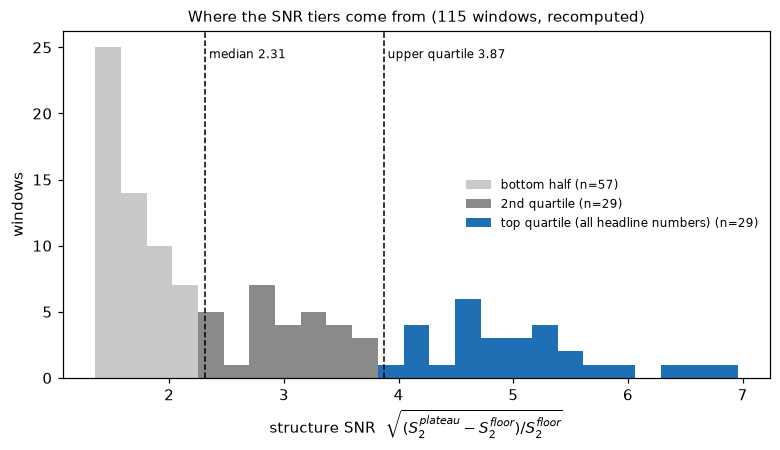

In [10]:
fig, ax = plt.subplots(figsize=(7.2, 4.2))
bins = np.linspace(audit.snr.min(), audit.snr.max(), 26)
for tier, colour, lab in [('bottom_half', '#c9c9c9', 'bottom half'),
                          ('q3', '#8a8a8a', '2nd quartile'),
                          ('q4', '#1f6fb4', 'top quartile (all headline numbers)')]:
    s = audit[audit.tier == tier].snr
    ax.hist(s, bins=bins, color=colour, label='%s (n=%d)' % (lab, len(s)))
for x, lab in [(q50, 'median %.2f' % q50), (q75, 'upper quartile %.2f' % q75)]:
    ax.axvline(x, color='k', lw=1, ls='--')
    ax.text(x, ax.get_ylim()[1] * 0.95, ' ' + lab, fontsize=8, va='top')
ax.set_xlabel('structure SNR  $\\sqrt{(S_2^{plateau} - S_2^{floor})/S_2^{floor}}$')
ax.set_ylabel('windows')
ax.set_title('Where the SNR tiers come from (%d windows, recomputed)' % len(audit),
             fontsize=10)
ax.legend(fontsize=8, frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(RERUN, 'results', 'snr_tiers.png'), dpi=130,
            bbox_inches='tight')
print('wrote rerun/results/snr_tiers.png')
fig

## 3. The single-band fits: 29 top-SNR windows at k = 3

This is the table behind every headline number. One fit per window on the
r < 0.1 ly band, plus 9 jackknife refits each — about 22 s per window, run
across `PROCS` workers.

`_one_window` caches its result as JSON keyed on the window, so re-executing
this cell is free and an interrupted run resumes. `summarize` then collapses the
per-window JSON into the CSV that everything downstream reads.

In [11]:
q4_specs = [(int(r.row), int(r.col)) for _, r in
            audit[audit.tier == 'q4'].sort_values(['row', 'col']).iterrows()]
print('top-SNR quartile: %d windows' % len(q4_specs))

out_dir_k3 = os.path.join(RERUN, 'data', 'singleband_r0.1_s2_k3')
jobs = [(r, c, 400, STRIDE, RCUT, out_dir_k3, 3) for r, c in q4_specs]

t0 = time.time()
paths = []
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    with Pool(PROCS) as pool:
        for i, (p, how) in enumerate(pool.imap_unordered(sbp._one_window, jobs), 1):
            paths.append(p)
            if i % 5 == 0 or i == len(jobs):
                print('  %2d/%d  %s  %.0fs' % (i, len(jobs), how,
                                               time.time() - t0), flush=True)
print('fits done in %.1f min' % ((time.time() - t0) / 60))

csv_k3 = os.path.join(RERUN, 'results', 'singleband_powerlaw_r0.1_s2_k3.csv')
rows_k3 = sbp.summarize(sorted(paths), csv_k3)
print('wrote %s (%d rows)' % (os.path.relpath(csv_k3, ROOT), len(rows_k3)))

top-SNR quartile: 29 windows
   5/29  cached  1s
  10/29  cached  1s
  15/29  cached  1s
  20/29  cached  1s
  25/29  cached  1s
  29/29  cached  1s
fits done in 0.0 min
wrote rerun/results/singleband_powerlaw_r0.1_s2_k3.csv (116 rows)


In [12]:
# Compare the recomputed fit table against the tracked one, window by window.
new = pd.read_csv(csv_k3)
new = new[(new['mode'] == '3d') & (new.profile == 'powerlaw')]
old = pd.read_csv(os.path.join(ROOT, 'results',
                               'singleband_powerlaw_r0.1_s2_k3.csv'))
old = old[(old['mode'] == '3d') & (old.profile == 'powerlaw')]
j = new.merge(old, on=['row', 'col'], suffixes=('_new', '_ref'))
print('windows matched: %d' % len(j))
print()
print('%-8s %11s %11s   %s' % ('quantity', 'max |diff|', 'max rel', 'note'))
for c in ['a2a1', 'a3a2', 'incl', 'alpha', 'se_a2a1', 'se_a3a2']:
    a, b = j[c + '_new'].values, j[c + '_ref'].values
    ok = np.isfinite(a) & np.isfinite(b)
    d = np.abs(a[ok] - b[ok])
    rel = d / np.maximum(np.abs(b[ok]), 1e-30)
    print('%-8s %11.3e %11.3e   %s'
          % (c, d.max(), rel.max(),
             'bit-identical' if d.max() == 0 else 'within tolerance'))
print()
print('The fits are deterministic -- no random seed anywhere in the single-band')
print('path -- so anything but ~0 here means an environment or data difference,')
print('not noise.')

windows matched: 29

quantity  max |diff|     max rel   note
a2a1       0.000e+00   0.000e+00   bit-identical
a3a2       0.000e+00   0.000e+00   bit-identical
incl       0.000e+00   0.000e+00   bit-identical
alpha      0.000e+00   0.000e+00   bit-identical
se_a2a1    0.000e+00   0.000e+00   bit-identical
se_a3a2    0.000e+00   0.000e+00   bit-identical

The fits are deterministic -- no random seed anywhere in the single-band
path -- so anything but ~0 here means an environment or data difference,
not noise.


### 3.2 The headline shape, from the table just computed

Maximum-likelihood common value plus intrinsic scatter, in log space, over the
29 windows. This is report §1.2 and §1.5, computed from the rerun table rather
than the tracked one.

In [13]:
# Use the canonical estimators, not hand-rolled arithmetic: mtf's wrapper takes
# LINEAR values and also returns the error on the centre, which is what the
# report quotes.  shape_center.prolateness is the log-symmetric prolate/oblate
# statistic (it replaced triaxiality T, which saturates on this cloud).
import shape_center as sc
import make_tier_figures as mtf

d = new[mtf.usable(new)].copy()
print('n windows usable   : %d of %d' % (len(d), len(new)))
print()
for c, lab, rep in [('a2a1', 'a2/a1', 0.285), ('a3a2', 'a3/a2', 0.601)]:
    mu, sig, se_mu, med_se = mtf.ml_center_and_scatter(d[c].values,
                                                       d['se_' + c].values)
    print('%-6s common %.4f   intrinsic scatter %.3f dex   se_mu %.3f dex'
          % (lab, 10 ** mu, sig, se_mu))
    print('%-6s report %.3f +- %.3f dex        median meas SE %.3f dex'
          % ('', rep, {0.285: 0.039, 0.601: 0.025}[rep], med_se))

mu21, _, _, _ = mtf.ml_center_and_scatter(d.a2a1.values, d.se_a2a1.values)
mu32, _, _, _ = mtf.ml_center_and_scatter(d.a3a2.values, d.se_a3a2.values)
print()
print('axes : 1 : %.3f : %.3f' % (10 ** mu21, 10 ** (mu21 + mu32)))

pro = sc.prolateness(d.a2a1.values, d.a3a2.values)
spro = np.hypot(d.se_a2a1.values / (d.a2a1.values * np.log(10)),
                d.se_a3a2.values / (d.a3a2.values * np.log(10)))
pmu, psig, pse, _ = mtf.ml_center_and_scatter(10 ** pro, 10 ** pro * spro
                                              * np.log(10))
print()
print('prolateness = %+.4f +- %.4f dex  ->  %.1f sigma prolate'
      % (pmu, pse, pmu / pse))
print('report      : +0.350 +- 0.051 dex, 6.9 sigma')
print()
print('on the prolate side : %d of %d windows' % ((pro > 0).sum(), len(pro)))

n windows usable   : 29 of 29

a2/a1  common 0.2854   intrinsic scatter 0.120 dex   se_mu 0.039 dex
       report 0.285 +- 0.039 dex        median meas SE 0.210 dex
a3/a2  common 0.6008   intrinsic scatter 0.096 dex   se_mu 0.025 dex
       report 0.601 +- 0.025 dex        median meas SE 0.078 dex

axes : 1 : 0.285 : 0.171

prolateness = +0.3497 +- 0.0506 dex  ->  6.9 sigma prolate
report      : +0.350 +- 0.051 dex, 6.9 sigma

on the prolate side : 25 of 29 windows


## 4. All 115 windows at k = 4

The figures need every window, not just the top quartile, and they use the
`k=4` blocking. This is the expensive step: 115 windows × 17 fits ≈ 12 min on
6 workers. Skipped when `RUN_LEVEL='walkthrough'`.

Worth being explicit about why both blockings exist in the repo, because it is
easy to read as sloppiness: the tracked `k=3` table contains **only** the 29
top-quartile windows, so it cannot populate a three-tier figure. The `k=4` table
covers all 115. Headline numbers are quoted at `k=3`, figures drawn at `k=4`,
and the ~1.5 % difference between them is the blocking systematic — far smaller
than the 0.12 dex intrinsic scatter that is the actual result.

In [14]:
csv_k4 = os.path.join(RERUN, 'results', 'singleband_powerlaw_r0.1_s2_k4.csv')

if LEVEL < 1:
    print("RUN_LEVEL='walkthrough' -> skipping the 115-window k=4 run.")
    print('Set RUN_LEVEL=\'figures\' to compute it (~12 min).')
else:
    all_specs = [(int(r.row), int(r.col)) for _, r in windows.iterrows()]
    out_dir_k4 = os.path.join(RERUN, 'data', 'singleband_r0.1_s2_k4')
    jobs4 = [(r, c, 400, STRIDE, RCUT, out_dir_k4, 4) for r, c in all_specs]
    t0 = time.time()
    paths4 = []
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        with Pool(PROCS) as pool:
            for i, (p, how) in enumerate(
                    pool.imap_unordered(sbp._one_window, jobs4), 1):
                paths4.append(p)
                if i % 10 == 0 or i == len(jobs4):
                    print('  %3d/%d  %s  %.0fs'
                          % (i, len(jobs4), how, time.time() - t0), flush=True)
    print('fits done in %.1f min' % ((time.time() - t0) / 60))
    rows_k4 = sbp.summarize(sorted(paths4), csv_k4)
    print('wrote %s (%d rows)' % (os.path.relpath(csv_k4, ROOT), len(rows_k4)))

   10/115  cached  1s
   20/115  cached  1s
   30/115  cached  1s
   40/115  cached  1s
   50/115  cached  1s
   60/115  cached  1s
   70/115  cached  1s
   80/115  cached  1s
   90/115  cached  1s
  100/115  cached  1s
  110/115  cached  1s
  115/115  cached  1s
fits done in 0.0 min
wrote rerun/results/singleband_powerlaw_r0.1_s2_k4.csv (460 rows)


## 5. The figures, from the tables just computed

`make_tier_figures.main` reads its inputs from module-level `ROOT`, so pointing
that at `rerun/` makes it draw from what this notebook computed instead of the
tracked tables. Both published figures are regenerated and then compared, pixel
by pixel, against the committed versions.

The standing rule this code implements: the display clip that drops collapsed
fits (ratios ~10⁻¹⁶) affects only what is **drawn**. The maximum-likelihood fits
always use the full usable sample, so no printed number moves when a display
threshold is retuned — that is the check, not a detail.

In [15]:
import importlib
import make_tier_figures as mtf
importlib.reload(mtf)

if LEVEL < 1:
    print("RUN_LEVEL='walkthrough' -> no k=4 table, so no figures.")
else:
    saved_root = mtf.ROOT
    fig_dir = os.path.join(RERUN, 'results', 'figures')
    try:
        mtf.ROOT = RERUN          # draw from the rerun tables
        mtf.main(k=4, outdir=fig_dir)
    finally:
        mtf.ROOT = saved_root
    print()
    print('n_drawn should be 100 of 115: at k=3 it would be 29, which is the')
    print('diagnostic that the lower two tiers have silently collapsed.')

k=4  n_drawn=100  range=[0.080, 1.143]
common shape  a2/a1=0.2811  a3/a2=0.5958
intrinsic sig 0.127, 0.100 dex | median meas SE 0.248, 0.073 dex
wrote /Users/jegpeek/Repositories/casa/rerun/results/figures/b2b1_vs_inclination_all115.png
      /Users/jegpeek/Repositories/casa/rerun/results/figures/shape_plane_all115.png

n_drawn should be 100 of 115: at k=3 it would be 29, which is the
diagnostic that the lower two tiers have silently collapsed.


In [16]:
import hashlib

if LEVEL >= 1:
    def sha(p):
        return hashlib.sha256(open(p, 'rb').read()).hexdigest()[:16]

    for name in ['shape_plane_all115.png', 'b2b1_vs_inclination_all115.png']:
        a = os.path.join(RERUN, 'results', 'figures', name)
        b = os.path.join(ROOT, 'results', 'figures', name)
        if os.path.exists(b):
            same = sha(a) == sha(b)
            print('%-34s rerun %s  committed %s  %s'
                  % (name, sha(a), sha(b),
                     'IDENTICAL' if same else 'DIFFERS'))
        else:
            print('%-34s rerun %s  (no committed copy)' % (name, sha(a)))

shape_plane_all115.png             rerun a4cf239fba131d77  committed a4cf239fba131d77  IDENTICAL
b2b1_vs_inclination_all115.png     rerun bdc43b3ea07087b6  committed bdc43b3ea07087b6  IDENTICAL


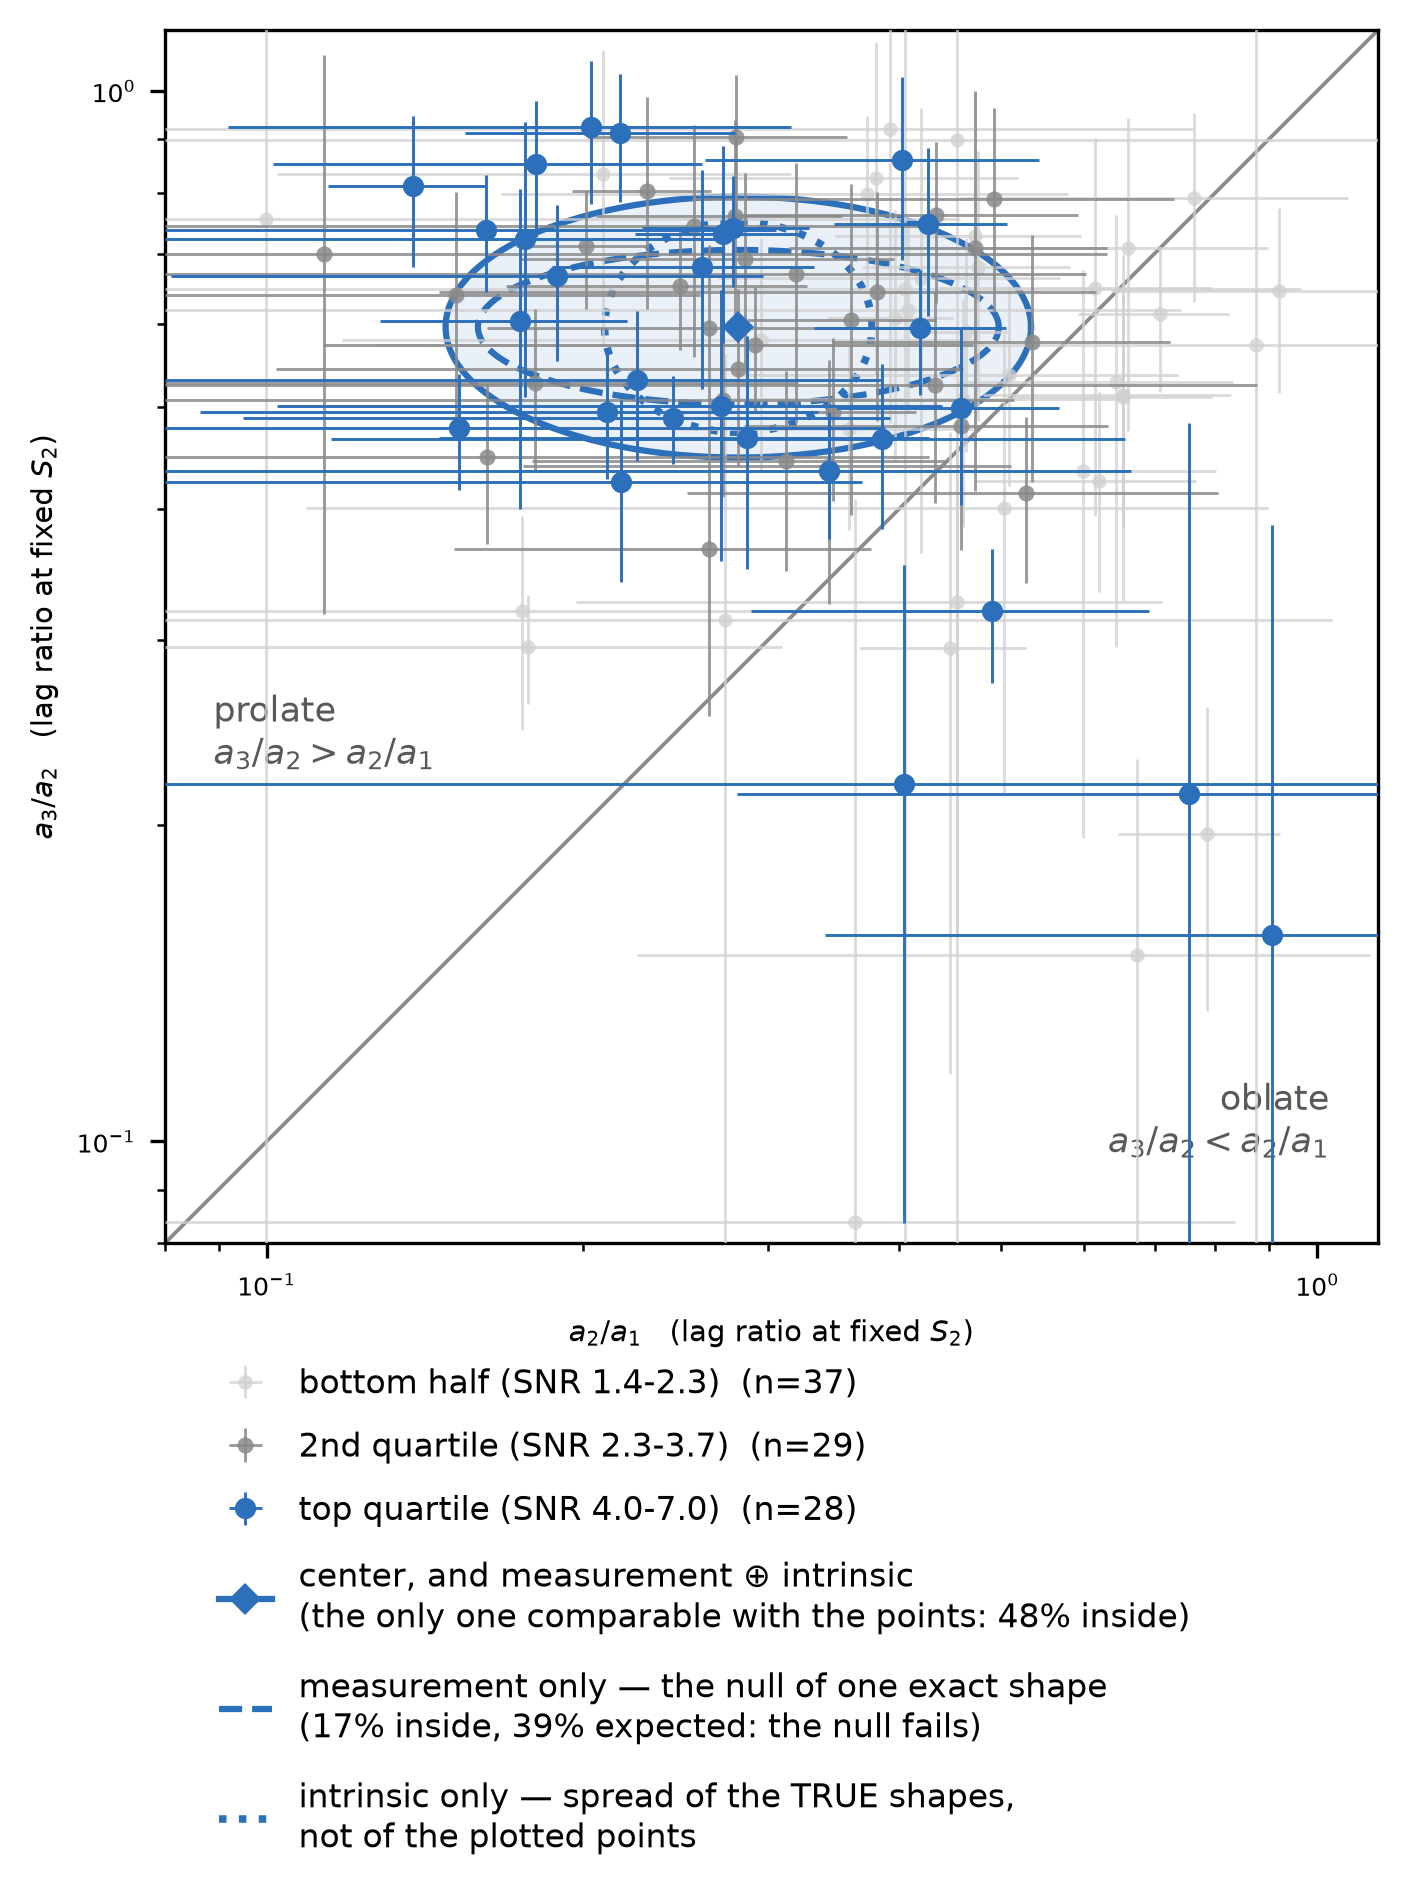

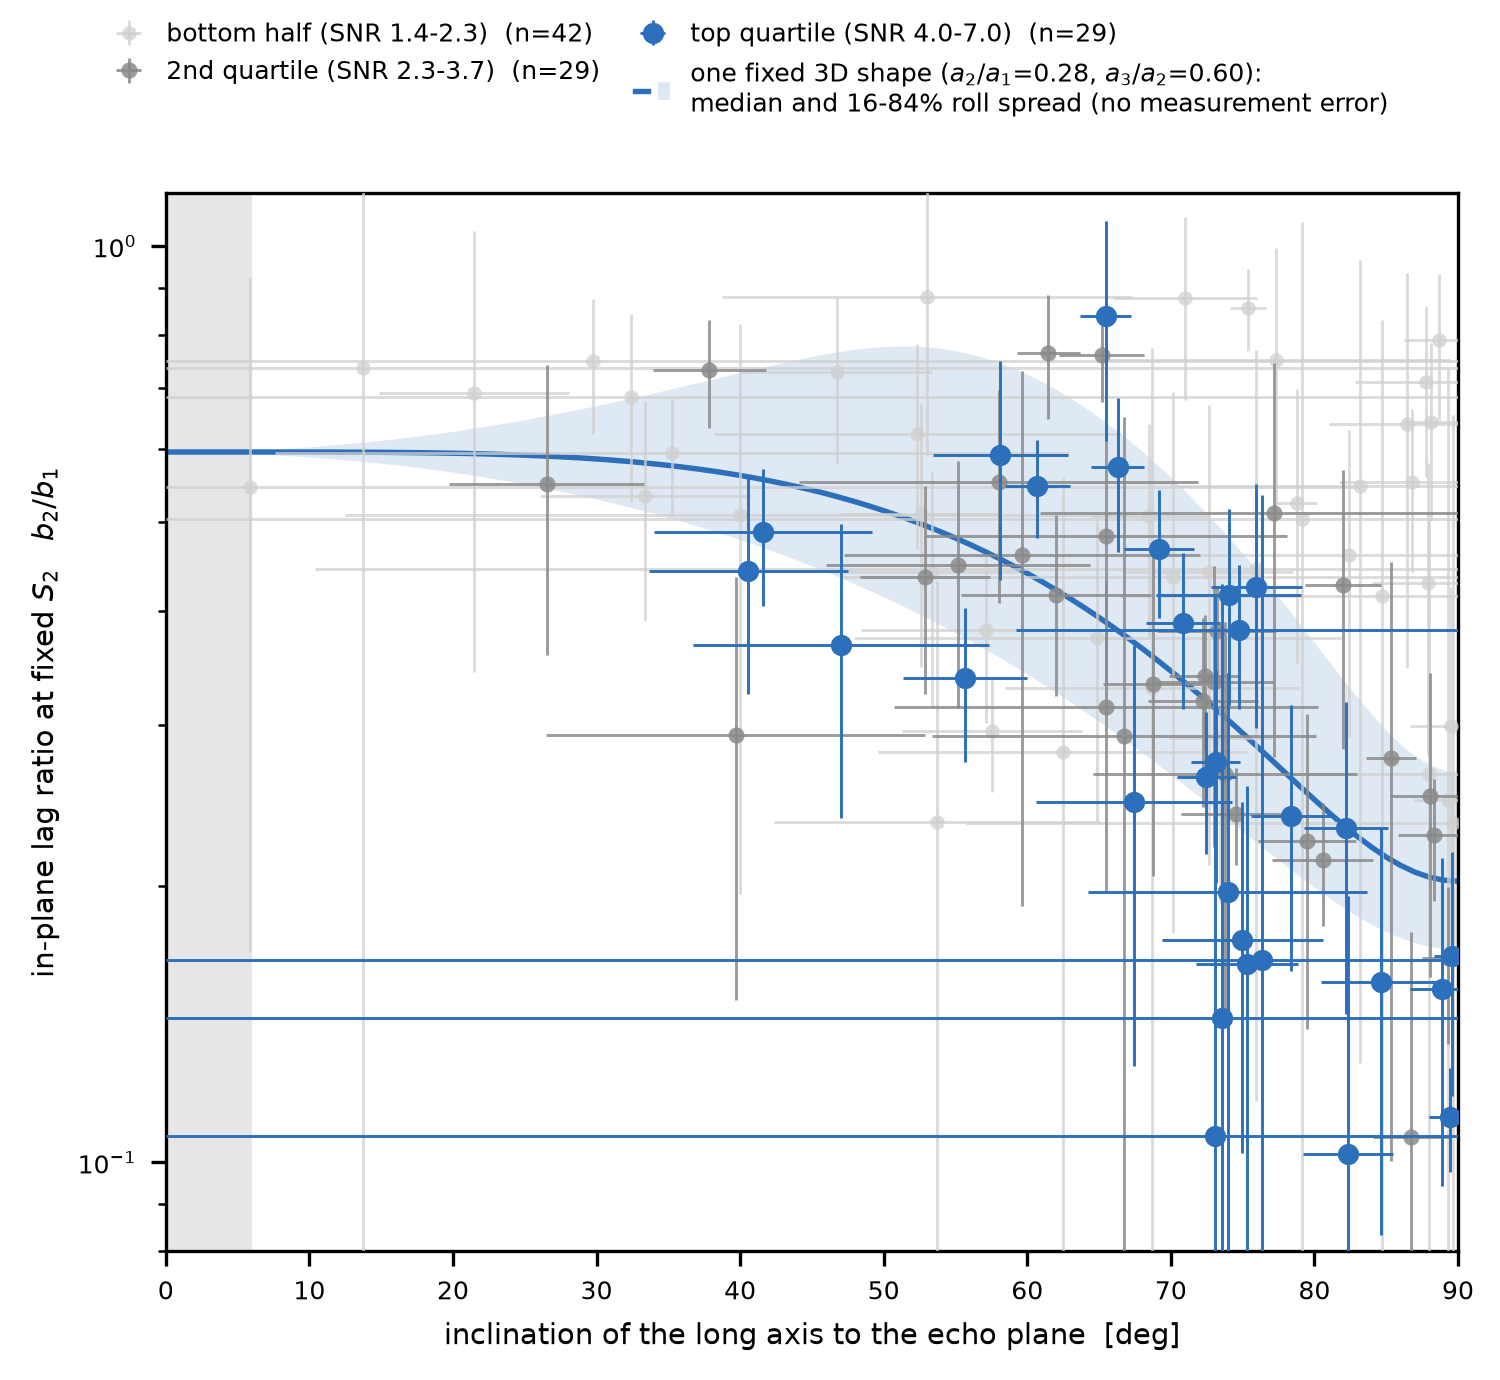

In [17]:
from IPython.display import Image, display

if LEVEL >= 1:
    for name in ['shape_plane_all115.png', 'b2b1_vs_inclination_all115.png']:
        display(Image(filename=os.path.join(RERUN, 'results', 'figures', name),
                      width=760))

## 6. The scale profile (`RUN_LEVEL='full'`)

Does the shape depend on the scale you measure it at? Fitting five overlapping
0.6-dex lag bands per window answers it, and it is the most expensive thing in
the repo: one window takes ~6 min because each band is a separate fit with its
own jackknife, so 29 windows is ~30 min on 6 workers.

The result (report §1.8) is that structures flatten with scale, carried entirely
by the short axis: a₃/a₂ falls −0.24/dex while a₂/a₁ is scale-invariant. This
cell is gated because the conclusion is already in the tracked tables; set
`RUN_LEVEL='full'` to regenerate it.

In [18]:
import scale_profile as sp
import summarize_scale_profile as ssp

if LEVEL < 2:
    print("RUN_LEVEL='%s' -> skipping the scale profile (~30 min)." % RUN_LEVEL)
    print("Set RUN_LEVEL='full' to run it.")
    print()
    print('Tracked result, for reference (results/scale_profile_slopes_summary.csv):')
    s = pd.read_csv(os.path.join(ROOT, 'results',
                                 'scale_profile_slopes_summary.csv'))
    print(s.to_string(index=False))
else:
    sp_dir = os.path.join(RERUN, 'data', 'scale_profile_d0.6_s2')
    os.makedirs(sp_dir, exist_ok=True)
    sp_specs = [(r, c, 400, STRIDE, sp_dir, 0.6) for r, c in q4_specs]
    t0 = time.time()
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        with Pool(PROCS) as pool:
            for i, (p, how) in enumerate(
                    pool.imap_unordered(sp._one_window, sp_specs), 1):
                print('  %2d/%d %s %.0fs' % (i, len(sp_specs), how,
                                             time.time() - t0), flush=True)
    print('scale profile done in %.1f min' % ((time.time() - t0) / 60))

   1/29 cached 1s
   2/29 cached 1s
   3/29 cached 1s
   4/29 cached 1s
   5/29 cached 1s
   6/29 cached 1s
   7/29 cached 1s
   8/29 cached 1s
   9/29 cached 1s
  10/29 cached 1s
  11/29 cached 1s
  12/29 cached 1s
  13/29 cached 1s
  14/29 cached 1s
  15/29 cached 1s
  16/29 cached 1s
  17/29 cached 1s
  18/29 cached 1s
  19/29 cached 1s
  20/29 cached 1s
  21/29 cached 1s
  22/29 cached 1s
  23/29 cached 1s
  24/29 cached 1s
  25/29 cached 1s
  26/29 cached 1s
  27/29 cached 1s
  28/29 cached 1s
  29/29 cached 1s
scale profile done in 0.0 min


Now aggregate those per-window fits and compare against the tracked table. The
aggregation is a median with a Wilcoxon signed-rank test rather than an
inverse-variance weighted mean: the slopes have heavy tails and one
badly-determined window would otherwise dominate.

Note the sample is 27 windows, not 29. Two windows have fewer than three
usable bands — the widest bands run into the window size — and a slope needs
three points, so they drop out. That is a property of the data, not a filter
applied by hand.

In [19]:
import summarize_scale_slopes as sss

if LEVEL < 2:
    print("RUN_LEVEL='%s' -> nothing recomputed to compare." % RUN_LEVEL)
else:
    band_rows, slope_rows = ssp.summarize(stride=STRIDE, band_dex=0.6,
                                          data_dir=os.path.join(RERUN, 'data'))
    bands_re = pd.DataFrame(band_rows)
    bands_re.to_csv(os.path.join(RERUN, 'results',
                                 'scale_profile_d0.6_s2_bands.csv'), index=False)
    pd.DataFrame(slope_rows).to_csv(
        os.path.join(RERUN, 'results', 'scale_profile_d0.6_s2_slopes.csv'),
        index=False)

    got = sss.summarize(bands_re)
    got.to_csv(os.path.join(RERUN, 'results',
                            'scale_profile_slopes_summary.csv'), index=False)
    want = pd.read_csv(os.path.join(ROOT, 'results',
                                    'scale_profile_slopes_summary.csv'))
    m = want.merge(got, on=['measure', 'subset'], suffixes=('_w', '_g'))
    print('%-22s %-18s %10s %10s %12s %12s'
          % ('measure', 'subset', 'tracked', 'rerun', 'p tracked', 'p rerun'))
    for _, r in m.iterrows():
        print('%-22s %-18s %+10.4f %+10.4f %12.2e %12.2e'
              % (r['measure'], r['subset'], r['slope_per_dex_w'],
                 r['slope_per_dex_g'], r['wilcoxon_p_w'], r['wilcoxon_p_g']))
    print()
    print('max |diff| in slope_per_dex : %.3e'
          % np.abs(m.slope_per_dex_w - m.slope_per_dex_g).max())
    print('windows used                : %s (tracked %s)'
          % (sorted(set(got.n_windows)), sorted(set(want.n_windows))))

    # Where the residual difference lives: per band, usable vs not.
    bw = pd.read_csv(os.path.join(ROOT, 'results',
                                  'scale_profile_d0.6_s2_bands.csv'))
    mb = bw.merge(bands_re, on=['chunk', 'band'], suffixes=('_w', '_g'))
    rel = (np.abs(mb.a2a1_w - mb.a2a1_g) / np.abs(mb.a2a1_w)).values
    ok = mb.usable_w.values.astype(bool)
    print()
    print('per-band relative |diff| in a2a1 (%d bands):' % len(mb))
    print('   median        %.1e' % np.nanmedian(rel))
    print('   max, usable   %.1e   (%d bands)' % (np.nanmax(rel[ok]), ok.sum()))
    print('   max, unusable %.1e   (%d bands, collapsed fits on a boundary)'
          % (np.nanmax(rel[~ok]), (~ok).sum()))
    print('   usable flag disagreements: %d'
          % int((mb.usable_w.astype(bool) != mb.usable_g.astype(bool)).sum()))

measure                subset                tracked      rerun    p tracked      p rerun
p = ln(a1 a3/a2^2)     all_5_bands           -0.6423    -0.6423     3.81e-04     3.81e-04
p = ln(a1 a3/a2^2)     outermost_dropped     -0.3495    -0.3496     7.72e-02     7.72e-02
T (triaxiality)        all_5_bands           -0.0210    -0.0210     1.17e-01     1.17e-01
T (triaxiality)        outermost_dropped     +0.0132    +0.0132     9.34e-01     9.34e-01
a3/a1                  all_5_bands           -0.0833    -0.0833     1.35e-05     1.35e-05
a3/a1                  outermost_dropped     -0.1405    -0.1405     2.98e-08     2.98e-08
a3/a2                  all_5_bands           -0.2409    -0.2409     7.45e-08     7.45e-08
a3/a2                  outermost_dropped     -0.2843    -0.2843     1.04e-07     1.04e-07
a2/a1                  all_5_bands           -0.0118    -0.0118     6.62e-01     6.62e-01
a2/a1                  outermost_dropped     -0.0860    -0.0860     4.63e-02     4.63e-02
alpha (pro

Unlike §3, this does **not** come out bit-identical, and it is worth being
precise about why rather than waving at "numerical noise".

The per-band fits agree to a median relative difference of ~10⁻⁸, and every
band that differs by more than 10⁻³ is one already flagged unusable — a
collapsed fit sitting on a parameter boundary, where the objective is flat and
the optimizer's stopping point is not well determined. No usable band differs
by more than ~10⁻⁴, `usable` is assigned identically for all 145 bands, and
the aggregated slopes therefore agree to ~10⁻⁵.

Re-running a single window twice in *this* environment reproduces bit-for-bit,
so the fits are deterministic; there is no random start. The differences are
against a table generated on a different day. That reading is supported by
which tables reproduce exactly: `singleband_powerlaw_r0.1_s2_k3.csv` was
regenerated most recently and is bit-identical, while `noise_audit_table.csv`
and the scale-profile tables are older and agree to floating-point tolerance
instead. Bit-identity across environments is not something this pipeline
promises — agreement far inside the error bars is, and 10⁻⁵ against a quoted
slope of −0.24 ± 0.04 is four orders of magnitude inside it.

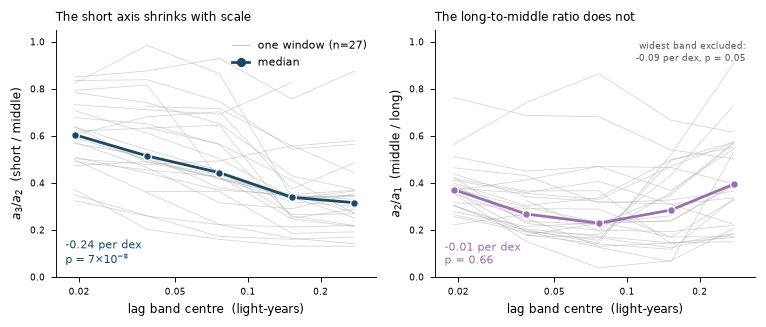

In [20]:
import make_scale_profile_figure as mspf

if LEVEL >= 2:
    fig = mspf.make(bands_re, got,
                    os.path.join(RERUN, 'results', 'scale_profile_ratios.png'))
fig

The headline of this section is the pair of rows for `a3/a2` and `a2/a1`: the
short axis shrinks relative to the middle one at roughly −0.24 per dex of lag,
while the long-to-middle ratio is flat. Structures get *flatter* with scale
without getting less elongated — which is why "prolate becomes triaxial" is a
misleading way to say it.

## 7. What this run produced

Everything above wrote into `rerun/`, mirroring the repo's own layout. Nothing
tracked was modified, so the comparison cells are meaningful and a rerun is
always safe.

In [21]:
print('rerun/ tree:')
tot = 0
for base, dirs, files in os.walk(RERUN):
    dirs.sort()
    keep = [f for f in sorted(files) if not f.startswith('.')]
    if not keep:
        continue
    rel = os.path.relpath(base, RERUN)
    sz = sum(os.path.getsize(os.path.join(base, f)) for f in keep)
    tot += sz
    if len(keep) > 6:
        print('  %-42s %3d files  %7.1f MB' % (rel + '/', len(keep), sz / 1e6))
    else:
        print('  %s/' % rel)
        for f in keep:
            print('      %-38s %7.1f MB'
                  % (f, os.path.getsize(os.path.join(base, f)) / 1e6))
print('  total %.1f MB' % (tot / 1e6))

rerun/ tree:
  data/audit/                                115 files      0.0 MB
  data/scale_profile_d0.6_s2/                 29 files      0.7 MB
  data/singleband_r0.1_s2_k3/                 29 files      1.0 MB
  data/singleband_r0.1_s2_k4/                115 files      6.5 MB
  results/                                     9 files      1.4 MB
  results/figures/
      b2b1_vs_inclination_all115.png             0.2 MB
      shape_plane_all115.png                     0.2 MB
  total 10.0 MB


### Stages not run here, and why

* **`bootstrap_windows.py`** — 100 block-bootstrap replicates per window, the
  error-model cross-check on the jackknife. Costs about as much as §4 again and
  is orthogonal to the shape result.
* **`scale_profile_2d.py`** — the in-plane twin of §6, needed for the
  band-resolved variance decomposition in report §1.1.
* **`scale_split.py`** — the two-band inner/outer split, a coarser version of §6.
* **`jackknife_noise*.py`, `compare_noise_models.py`** — the Weibull-vs-power-law
  profile comparison and the noise-inflation audit.

All are documented in `REPRODUCING.md` with their commands. Each follows the
same pattern as §3: a `Pool` over per-window JSON caches, then a `summarize`
step into `results/`.

### If a number here disagrees with the report

Check in this order — every one of these has bitten someone on this project:

1. **Which `k`?** Headline numbers are `k=3`, figures `k=4`, and report §1.4's
   slope statistics are the unsuffixed `k=2`. Different files, all legitimate.
2. **Which tier?** Every headline number is the top-SNR quartile only.
3. **`mode == '3d'` or `'2d'`?** The `b2b1` column exists in both, and means
   different things: predicted slice on the 3D rows, independent measurement on
   the 2D rows.
4. **Which subset?** Report §1.8's net displacement uses only windows where all
   five lag bands converged (23 of 29), not all finite windows.